> # Local Testing mode

https://quantum.cloud.ibm.com/docs/en/guides/local-testing-mode

### 2 types of local testing mode:

-     1. Fake backends

-     2. Aer Simulator 


In [1]:
from platform import python_version
import qiskit
print("Python version ", python_version())
print(f"Qiskit version: {qiskit.__version__}")

Python version  3.13.5
Qiskit version: 2.5.0


> # Fake backends

qiskit_ibm_runtime.fake_provider mimic the behaviors of IBM QPUs by using QPU snapshots

In [2]:
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

# Run the Sampler job locally using FakeManilaV2
fake_manila= FakeManilaV2()

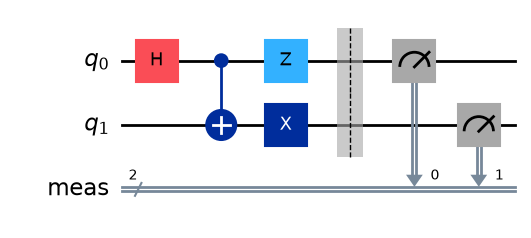

In [3]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Bell Circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.z(0)
qc.x(1)
qc.measure_all()
qc.draw("mpl")

In [4]:
pm = generate_preset_pass_manager(backend=fake_manila, optimization_level=1)
isa_qc = pm.run(qc)

from qiskit_ibm_runtime import SamplerV2 as Sampler
sampler = Sampler(mode=fake_manila)
result = sampler.run([isa_qc]).result()
pub_result = result[0]

{'00': 48, '10': 489, '01': 471, '11': 16}


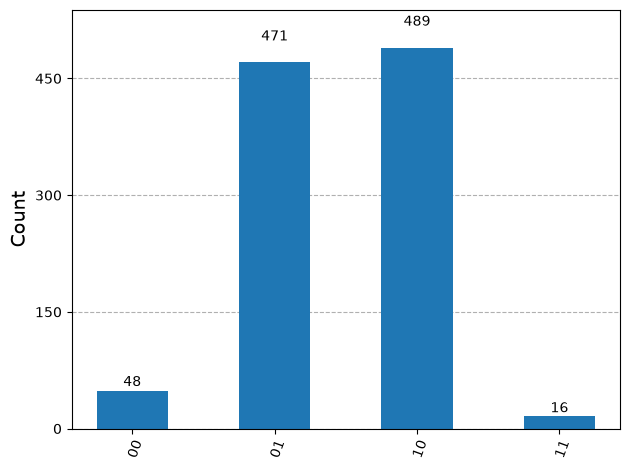

In [5]:
data= pub_result.data
counts_result=data.meas.get_counts()
print(counts_result)

from qiskit.visualization import plot_histogram
plot_histogram(counts_result)

> # Aer Simulator
from qiskit_aer import AerSimulator

higher-performance simulation that can handle larger circuits and custom noise models

In [6]:
from qiskit_aer import AerSimulator

# Run the Sampler job locally using AerSimulator.

# Session syntax is supported but ignored because local mode doesn't support sessions.

aer_sim = AerSimulator()

In [7]:
pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
isa_qc = pm.run(qc)

from qiskit_ibm_runtime import SamplerV2 as Sampler
sampler = Sampler(mode=aer_sim)
result = sampler.run([isa_qc]).result()
pub_result = result[0]

{'10': 508, '01': 516}


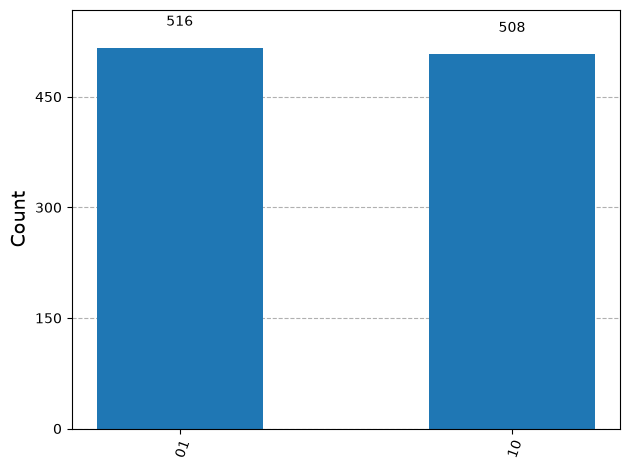

In [8]:
data= pub_result.data
counts_result=data.meas.get_counts()
print(counts_result)

from qiskit.visualization import plot_histogram
plot_histogram(counts_result)

**NOTE:** 
<h3>
 
 Local testing mode before executing on a real quantum hardware, helps to fine tunning

To simulate with noise, specify a QPU (quantum hardware) and submit it to Aer. 

Aer builds a noise model based on the calibration data from that QPU, and instantiates an Aer backend with that model.

The Executor primitive does not support local testing mode.

</h3>



> ### Basic workflow

Create quantum circuit

        ↓

Choose fake backend or AerSimulator

        ↓

Transpile circuit locally

        ↓

Run with Sampler/Estimator

        ↓

Analyze results

        ↓

Change backend name

        ↓

Run on real IBM QPU
